# Libraries & Data Setup

In [2]:
!pip install thop umap-learn

import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap
from sklearn.metrics import silhouette_score, accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from thop import profile

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dir = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'
test_dir = '/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task/test'

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

ssl_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=base_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=base_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.8 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.

2026-06-24 05:32:35.941033: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782279156.107971      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782279156.156933      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782279156.553127      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782279156.553171      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782279156.553174      58 computation_placer.cc:177] computation placer alr

# BYOL Architecture & Loss

In [3]:
class BYOL_DenseNet(nn.Module):
    def __init__(self, out_dim=256, hidden_dim=2048):
        super().__init__()
        self.online_encoder = models.densenet121(weights=None)
        dim_mlp = self.online_encoder.classifier.in_features
        self.online_encoder.classifier = nn.Identity()

        self.online_projector = nn.Sequential(
            nn.Linear(dim_mlp, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )
        self.online_predictor = nn.Sequential(
            nn.Linear(out_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

        self.target_encoder = copy.deepcopy(self.online_encoder)
        self.target_projector = copy.deepcopy(self.online_projector)

        for param in self.target_encoder.parameters():
            param.requires_grad = False
        for param in self.target_projector.parameters():
            param.requires_grad = False

    def forward(self, x1, x2):
        o1, o2 = self.online_encoder(x1), self.online_encoder(x2)
        z1_o, z2_o = self.online_projector(o1), self.online_projector(o2)
        p1_o, p2_o = self.online_predictor(z1_o), self.online_predictor(z2_o)

        with torch.no_grad():
            t1, t2 = self.target_encoder(x1), self.target_encoder(x2)
            z1_t, z2_t = self.target_projector(t1), self.target_projector(t2)

        return p1_o, p2_o, z1_t, z2_t

def byol_loss(p, z):
    p = F.normalize(p, dim=-1)
    z = F.normalize(z, dim=-1)
    return 2 - 2 * (p * z).sum(dim=-1).mean()

def update_target_network(online_net, target_net, tau=0.99):
    for online_params, target_params in zip(online_net.parameters(), target_net.parameters()):
        target_params.data = target_params.data * tau + online_params.data * (1 - tau)

# BYOL Pretraining

Epoch [1/10], Loss: 1.2504
Epoch [2/10], Loss: 1.0004
Epoch [3/10], Loss: 0.9143
Epoch [4/10], Loss: 0.9404
Epoch [5/10], Loss: 0.8400
Epoch [6/10], Loss: 0.7888
Epoch [7/10], Loss: 0.7595
Epoch [8/10], Loss: 0.6852
Epoch [9/10], Loss: 0.6691
Epoch [10/10], Loss: 0.5823

Pretraining Time: 1681.98 seconds


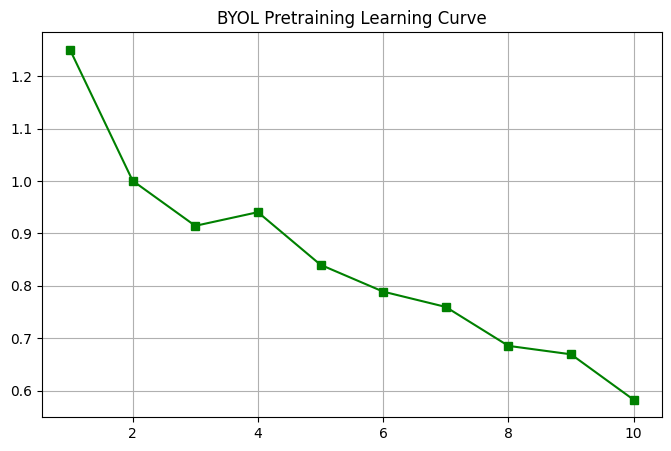

In [4]:
model = BYOL_DenseNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0003)
scaler = torch.amp.GradScaler('cuda')

epochs = 10
pretrain_losses = []
start_time = time.time()

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, _ in train_loader:
        torch.cuda.empty_cache()
        img1 = torch.stack([ssl_transform(transforms.ToPILImage()(img)) for img in images]).to(device)
        img2 = torch.stack([ssl_transform(transforms.ToPILImage()(img)) for img in images]).to(device)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            p1, p2, z1, z2 = model(img1, img2)
            loss = byol_loss(p1, z2) + byol_loss(p2, z1)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        update_target_network(model.online_encoder, model.target_encoder)
        update_target_network(model.online_projector, model.target_projector)
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    pretrain_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

print(f"\nPretraining Time: {time.time() - start_time:.2f} seconds")
torch.save(model.online_encoder.state_dict(), 'byol_frozen_encoder.pth')

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), pretrain_losses, marker='s', color='green')
plt.title('BYOL Pretraining Learning Curve')
plt.grid(True)
plt.show()

# BYOL Feature Analysis

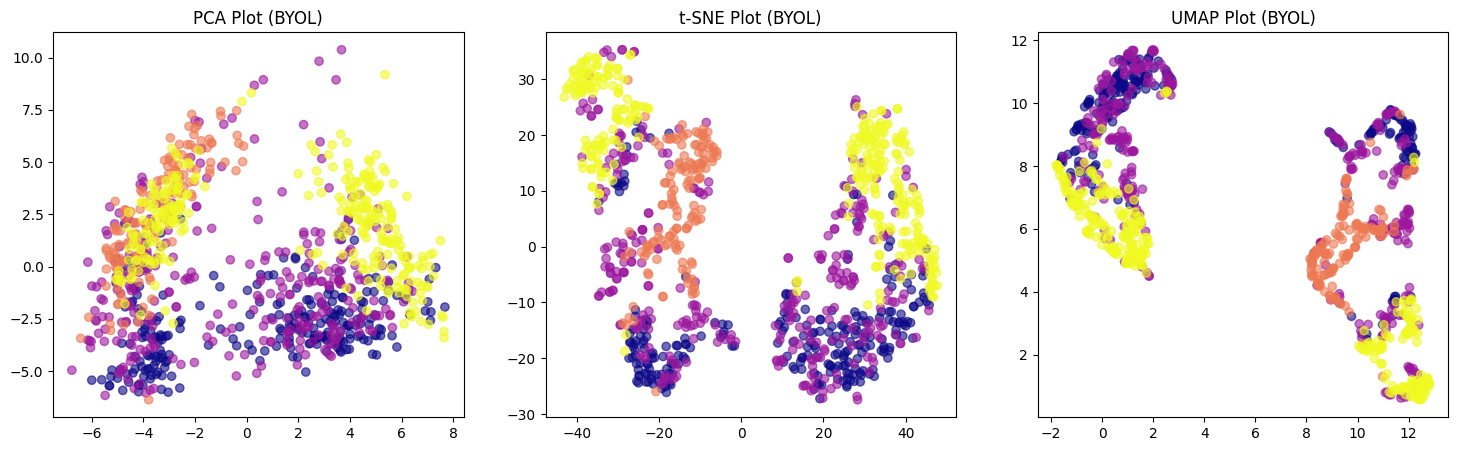

Silhouette Score (t-SNE): -0.0337


In [5]:
def extract_features_byol(model, dataloader):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs = imgs.to(device)
            h = model.online_encoder(imgs)
            features.append(h.cpu().numpy())
            labels.append(lbls.numpy())
    return np.concatenate(features), np.concatenate(labels)

X_train, y_train = extract_features_byol(model, train_loader)
X_test, y_test = extract_features_byol(model, test_loader)

pca_res = PCA(n_components=2).fit_transform(X_test)
tsne_res = TSNE(n_components=2, perplexity=30).fit_transform(X_test)
umap_res = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(X_test)

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1); plt.scatter(pca_res[:, 0], pca_res[:, 1], c=y_test, cmap='plasma', alpha=0.6); plt.title('PCA Plot (BYOL)')
plt.subplot(1, 3, 2); plt.scatter(tsne_res[:, 0], tsne_res[:, 1], c=y_test, cmap='plasma', alpha=0.6); plt.title('t-SNE Plot (BYOL)')
plt.subplot(1, 3, 3); plt.scatter(umap_res[:, 0], umap_res[:, 1], c=y_test, cmap='plasma', alpha=0.6); plt.title('UMAP Plot (BYOL)')
plt.show()

print(f"Silhouette Score (t-SNE): {silhouette_score(tsne_res, y_test):.4f}")

# BYOL Evaluation & Fine-Tuning

In [6]:
start_train = time.time()
lp_model = MLPClassifier(hidden_layer_sizes=(), max_iter=1000).fit(X_train, y_train)
print(f"Linear Probe Train Time: {time.time() - start_train:.4f} sec")

y_pred_lp = lp_model.predict(X_test)
y_prob_lp = lp_model.predict_proba(X_test)

shallow_heads = {
    "Linear Probe": lp_model,
    "SVM": SVC(probability=True).fit(X_train, y_train),
    "Random Forest": RandomForestClassifier().fit(X_train, y_train)
}

for name, clf in shallow_heads.items():
    print(f"{name} -> Accuracy: {clf.score(X_test, y_test):.4f}")

class FineTuneModel_BYOL(nn.Module):
    def __init__(self, base_encoder, num_classes):
        super().__init__()
        self.encoder = base_encoder
        self.classifier = nn.Linear(1024, num_classes)
    def forward(self, x):
        h = self.encoder(x)
        return self.classifier(h)

ft_model = FineTuneModel_BYOL(copy.deepcopy(model.online_encoder), len(train_dataset.classes)).to(device)
optimizer_ft = optim.Adam(ft_model.parameters(), lr=1e-5)
criterion_ft = nn.CrossEntropyLoss()

for epoch in range(5):
    ft_model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        loss = criterion_ft(ft_model(imgs), lbls)
        optimizer_ft.zero_grad(); loss.backward(); optimizer_ft.step()
    print(f"Fine-tuning Epoch {epoch+1}/5 complete.")

ft_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        _, predicted = torch.max(ft_model(imgs).data, 1)
        total += lbls.size(0); correct += (predicted == lbls).sum().item()
print(f"Full Fine-tuning Accuracy: {100 * correct / total:.2f}%")

Linear Probe Train Time: 7.5580 sec
Linear Probe -> Accuracy: 0.8030
SVM -> Accuracy: 0.8040
Random Forest -> Accuracy: 0.8890
Fine-tuning Epoch 1/5 complete.
Fine-tuning Epoch 2/5 complete.
Fine-tuning Epoch 3/5 complete.
Fine-tuning Epoch 4/5 complete.
Fine-tuning Epoch 5/5 complete.
Full Fine-tuning Accuracy: 82.20%


# BYOL Final Metrics & GFLOPs

k-NN (k=1) Accuracy: 0.9020
k-NN (k=5) Accuracy: 0.8280
k-NN (k=20) Accuracy: 0.7760

Classification Report:
              precision    recall  f1-score   support

      glioma       0.82      0.85      0.84       254
  meningioma       0.80      0.68      0.73       306
     notumor       0.68      0.64      0.66       140
   pituitary       0.84      0.97      0.90       300

    accuracy                           0.80      1000
   macro avg       0.79      0.78      0.78      1000
weighted avg       0.80      0.80      0.80      1000



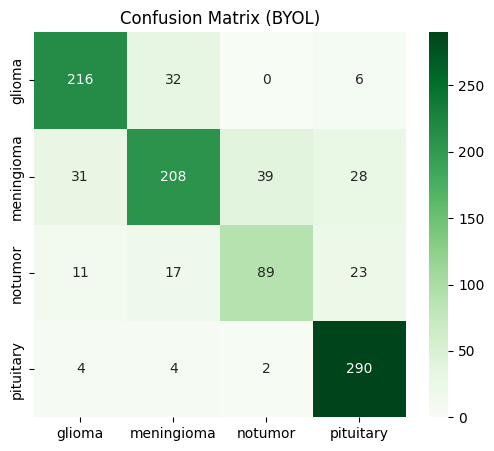

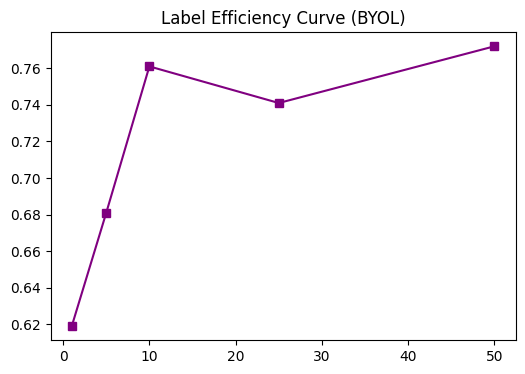

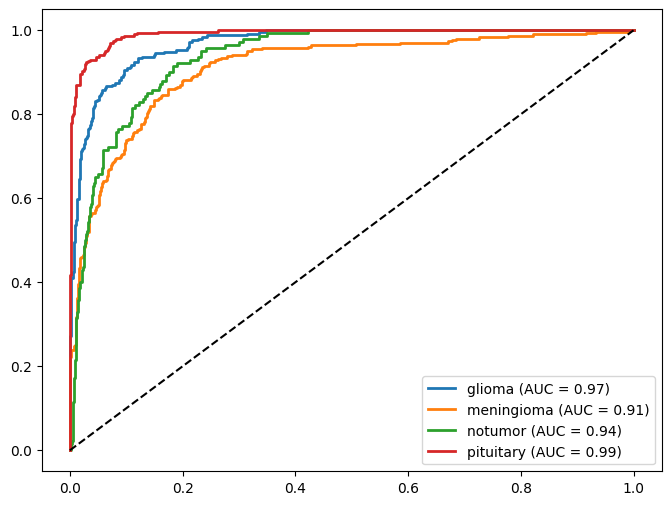


GFLOPs: 2.8960


In [7]:
for k in [1, 5, 20]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    print(f"k-NN (k={k}) Accuracy: {knn.score(X_test, y_test):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lp, target_names=train_dataset.classes))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lp), annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, cmap="Greens")
plt.title("Confusion Matrix (BYOL)")
plt.show()

def label_efficiency_curve(percentages):
    eff_accs = []
    for p in percentages:
        n = max(1, int(len(X_train) * (p / 100)))
        idx = np.random.choice(len(X_train), n, replace=False)
        lp = MLPClassifier(hidden_layer_sizes=(), max_iter=3000).fit(X_train[idx], y_train[idx])
        eff_accs.append(lp.score(X_test, y_test))
    return eff_accs

plt.figure(figsize=(6, 4))
plt.plot([1, 5, 10, 25, 50], label_efficiency_curve([1, 5, 10, 25, 50]), marker='s', color='purple')
plt.title("Label Efficiency Curve (BYOL)")
plt.show()

classes_list = list(range(len(train_dataset.classes)))
y_test_bin = label_binarize(y_test, classes=classes_list)
plt.figure(figsize=(8, 6))
for i in range(len(train_dataset.classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_lp[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'{train_dataset.classes[i]} (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'k--'); plt.legend(); plt.show()

input_dummy = torch.randn(1, 3, 224, 224).to(device)
macs, params = profile(model.online_encoder, inputs=(input_dummy,), verbose=False)
print(f"\nGFLOPs: {macs / 1e9:.4f}")